##               **RESUME SCREENING PROJECT**




In [166]:
# Importing the data sets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


  ## **Upload The Dataset**



In [167]:
df = pd.read_csv("ai_resume_screening.csv")
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes


In [168]:
df.shape

(30000, 7)

In [169]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [170]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [171]:
df.tail()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes
29999,14,77.3,Masters,25,694,790,Yes


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [173]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


         
 #       **Data Cleaning**

In [174]:
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [175]:
df.duplicated().sum()

np.int64(0)

#      **Exploratory Data Analysis**

In [176]:
df['shortlisted'].value_counts()

,count
shortlisted,
Yes,20966
No,9034


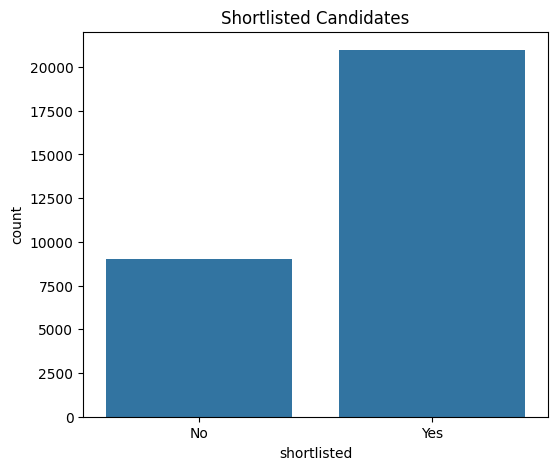

In [177]:
# To show the count of shortlisted candidates
plt.figure(figsize=(6,5))

sns.countplot(x='shortlisted',data=df)

plt.title("Shortlisted Candidates")
plt.show()

In [178]:
x=df["education_level"].value_counts()
x

,count
education_level,
Bachelors,13461
Masters,10524
PhD,3024
High School,2991


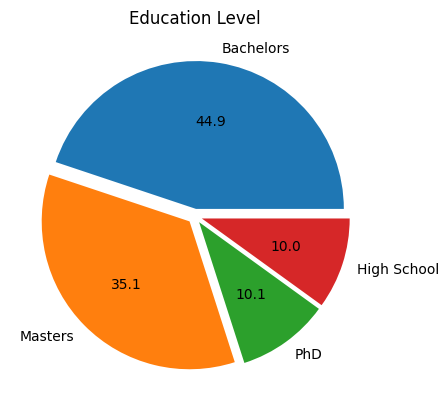

In [179]:
# Education level
plt.pie(x,labels=x.index,autopct='%1.1f',explode=[0.05,0.05,0.05,0.05])

plt.title("Education Level")
plt.show()

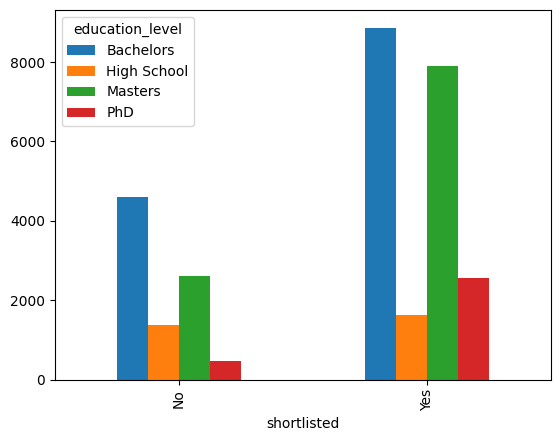

In [180]:
#shortlisted based on the Education Level

pd.crosstab(df["shortlisted"],df["education_level"]).plot(kind="bar")
plt.show()

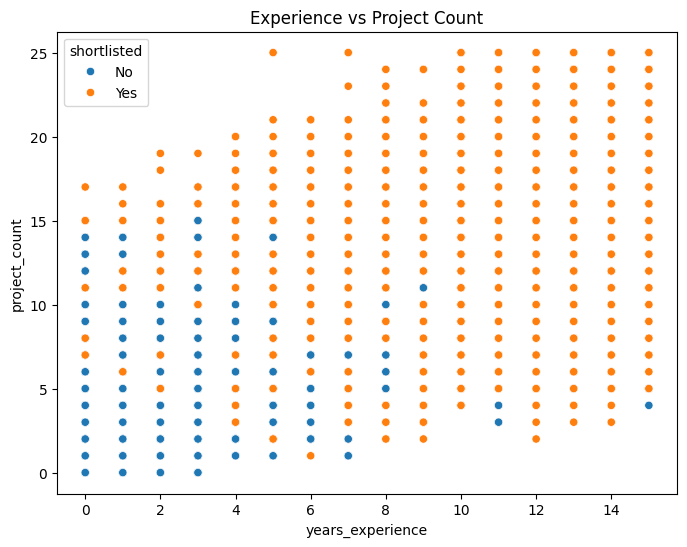

In [181]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='years_experience',
    y='project_count',
    hue='shortlisted',
    data=df
)

plt.title("Experience vs Project Count")
plt.show()

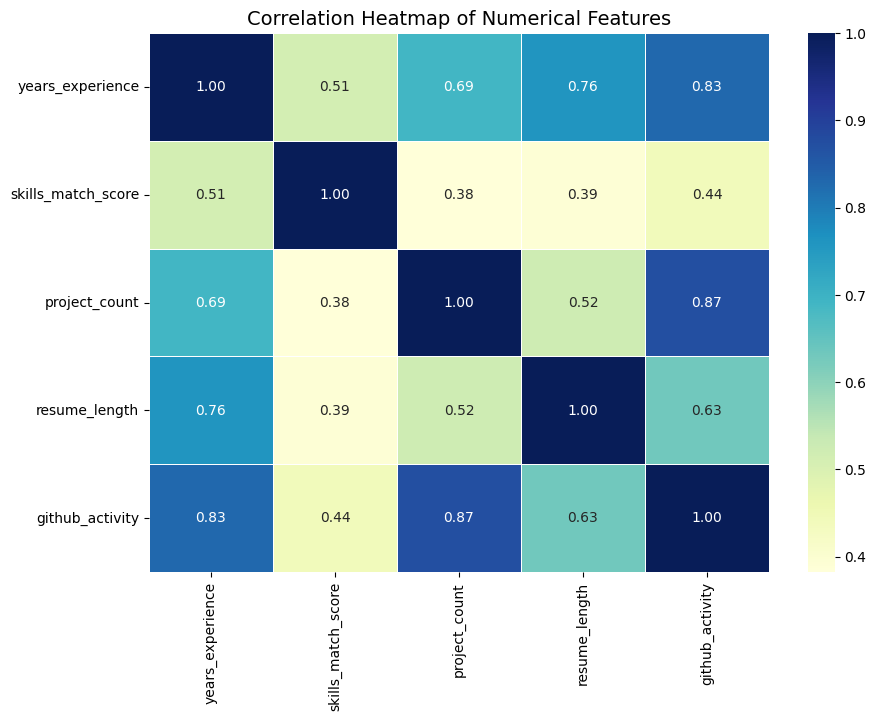

In [182]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5,
            fmt='.2f')

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

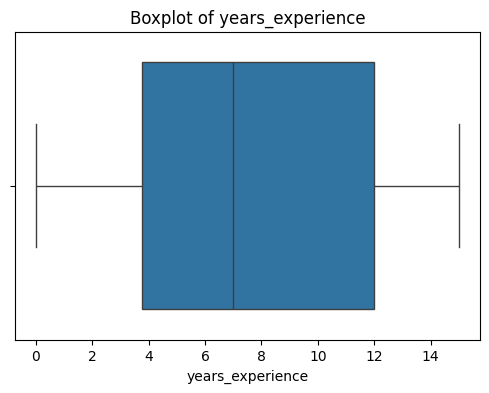

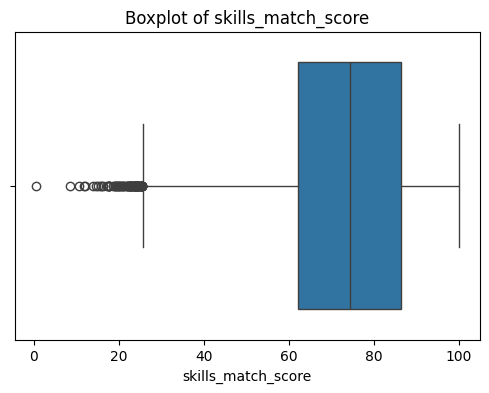

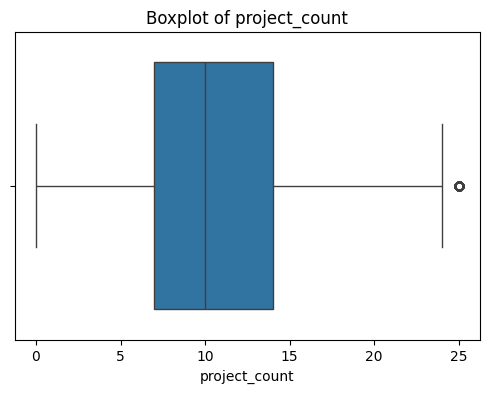

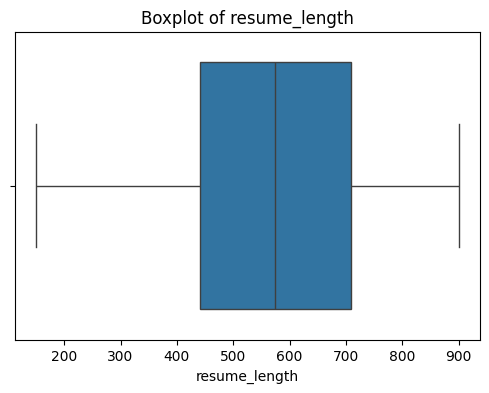

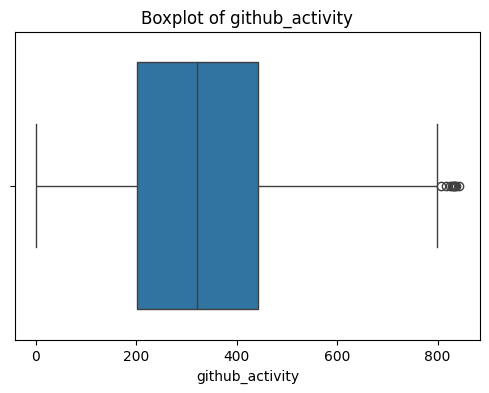

In [183]:
numerical_columns = [
    'years_experience',
    'skills_match_score',
    'project_count',
    'resume_length',
    'github_activity'
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Label Encoding




In [184]:
from sklearn.preprocessing import LabelEncoder


In [185]:
le = LabelEncoder()

In [186]:
df["education_level"]=le.fit_transform(df["education_level"])
df
# Bachelors --->0
# High School --->1
# Masters --->2
# PhD --->3


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,No
1,3,59.1,2,5,502,77,No
2,12,100.0,2,12,753,381,Yes
3,14,66.8,1,8,529,407,Yes
4,10,99.6,0,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434,Yes
29996,5,77.8,0,9,473,149,No
29997,1,64.6,0,7,247,82,No
29998,7,94.8,0,12,584,409,Yes


In [187]:
df["shortlisted"]=le.fit_transform(df["shortlisted"])
df
# No--->0
# Yes--->1

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1
...,...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434,1
29996,5,77.8,0,9,473,149,0
29997,1,64.6,0,7,247,82,0
29998,7,94.8,0,12,584,409,1


#Seperating the Target column


In [188]:
x=df.drop("shortlisted",axis=1)
x

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
0,6,84.7,0,7,234,158
1,3,59.1,2,5,502,77
2,12,100.0,2,12,753,381
3,14,66.8,1,8,529,407
4,10,99.6,0,10,754,331
...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434
29996,5,77.8,0,9,473,149
29997,1,64.6,0,7,247,82
29998,7,94.8,0,12,584,409


In [189]:
y=df["shortlisted"]
y

,shortlisted
0,0
1,0
2,1
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


In [190]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score


In [191]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,stratify=y)


#SMOTE

In [192]:
from imblearn.over_sampling import SMOTE

In [193]:
df['shortlisted'].value_counts()

,count
shortlisted,
1,20966
0,9034


In [194]:

smote=SMOTE()
rs_x,rs_y=smote.fit_resample(x,y)

##**Model** **Training**

In [195]:
# IMPORT MACHINE LEARNING ALGORITHMS

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 1. Logistic Regression

In [196]:
lr = LogisticRegression()

In [197]:
lr.fit(train_x, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [198]:
lr_pred = lr.predict(test_x)
lr_pred

array([0, 1, 0, ..., 1, 1, 1])

In [199]:
test_y

,shortlisted
3643,1
16238,1
11747,0
9243,0
19463,1
...,...
28612,1
5498,1
28637,1
27413,1


In [200]:
lr_accuracy=accuracy_score(test_y, lr_pred)*100
lr_accuracy


90.56666666666666

In [201]:
lr_precision=precision_score(test_y, lr_pred)*100
lr_precision


92.98411945958757

In [202]:
lr_recall=recall_score(test_y, lr_pred)*100
lr_recall


93.56069639875983

In [203]:
lr_f1_score=f1_score(test_y, lr_pred)*100
lr_f1_score

93.2715168806467

In [204]:
print("Accuracy :", accuracy_score(test_y, lr_pred))
print("Precision:", precision_score(test_y, lr_pred))
print("Recall   :", recall_score(test_y, lr_pred))
print("F1 Score :", f1_score(test_y, lr_pred))

print("\nClassification Report")
print(classification_report(test_y, lr_pred))


Accuracy : 0.9056666666666666
Precision: 0.9298411945958758
Recall   : 0.9356069639875984
F1 Score : 0.932715168806467

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.91      0.91      0.91      6000



# 2. Decision Tree





In [205]:
dt = DecisionTreeClassifier(criterion="entropy")

In [206]:
dt.fit(train_x,train_y)

DecisionTreeClassifier(criterion='entropy')

In [207]:
dt_pred = dt.predict(test_x)

In [208]:
dt_pred

array([0, 1, 1, ..., 1, 1, 1])

In [209]:
test_y

,shortlisted
3643,1
16238,1
11747,0
9243,0
19463,1
...,...
28612,1
5498,1
28637,1
27413,1


In [210]:
dt_accuracy=accuracy_score(test_y,dt_pred)*100
dt_accuracy

86.91666666666666

In [211]:
dt_precision=precision_score(test_y, dt_pred)*100
dt_precision


90.94185487746276

In [212]:
dt_recall=recall_score(test_y, dt_pred)*100
dt_recall

90.2694967803482

In [213]:
dt_f1_score=f1_score(test_y, dt_pred)*100
dt_f1_score

90.60442848593657

In [214]:
print("Accuracy :", accuracy_score(test_y, dt_pred))
print("Precision:", precision_score(test_y, dt_pred))
print("Recall   :", recall_score(test_y, dt_pred))
print("F1 Score :", f1_score(test_y, dt_pred))

print("\nClassification Report")
print(classification_report(test_y, dt_pred))


Accuracy : 0.8691666666666666
Precision: 0.9094185487746276
Recall   : 0.902694967803482
F1 Score : 0.9060442848593656

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.79      0.78      1807
           1       0.91      0.90      0.91      4193

    accuracy                           0.87      6000
   macro avg       0.84      0.85      0.85      6000
weighted avg       0.87      0.87      0.87      6000



##3. RandomForest

In [215]:
rf = RandomForestClassifier(n_estimators=100)

In [216]:
rf.fit(train_x,train_y)

RandomForestClassifier()

In [217]:
rf_pred=rf.predict(test_x)
rf_pred

array([0, 1, 0, ..., 1, 1, 1])

In [218]:
test_y

,shortlisted
3643,1
16238,1
11747,0
9243,0
19463,1
...,...
28612,1
5498,1
28637,1
27413,1


In [219]:
result = pd.DataFrame({
    "Actual": test_y,
    "Predicted": rf_pred
})

result.head(10)

,Actual,Predicted
3643,1,0
16238,1,1
11747,0,0
9243,0,0
19463,1,1
16948,1,1
8828,1,1
3292,0,0
15362,0,0
2627,1,1


In [220]:
rf_accuracy=accuracy_score(test_y,rf_pred)*100
rf_accuracy

90.48333333333333

In [221]:
rf_precision=precision_score(test_y, rf_pred)*100
rf_precision

92.81323877068559

In [222]:
rf_recall=recall_score(test_y, rf_pred)*100
rf_recall

93.6322442165514

In [223]:
rf_f1_score=f1_score(test_y, rf_pred)*100
rf_f1_score

93.22094265701057

In [224]:
print("Accuracy :", accuracy_score(test_y, rf_pred))
print("Precision:", precision_score(test_y, rf_pred))
print("Recall   :", recall_score(test_y, rf_pred))
print("F1 Score :", f1_score(test_y, rf_pred))

print("\nClassification Report")
print(classification_report(test_y, rf_pred))


Accuracy : 0.9048333333333334
Precision: 0.9281323877068558
Recall   : 0.936322442165514
F1 Score : 0.9322094265701056

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.89      0.88      0.89      6000
weighted avg       0.90      0.90      0.90      6000



#4.SVM

In [225]:
svm = SVC(kernel='rbf')

svm.fit(train_x, train_y)

svm_pred = svm.predict(test_x)

svm_accuracy = accuracy_score(test_y, svm_pred)*100
svm_precision = precision_score(test_y, svm_pred)*100
svm_recall = recall_score(test_y, svm_pred)*100
svm_f1_score = f1_score(test_y, svm_pred)*100

print("SVM Accuracy :", svm_accuracy)
print("SVM Precision :", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1_score :", svm_f1_score)

SVM Accuracy : 88.46666666666667
SVM Precision : 91.024138739161
SVM Recall: 92.63057476746958
SVM F1_score : 91.82033096926713


#5. XGBoost

In [226]:
!pip install xgboost

In [227]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(train_x, train_y)

xgb_pred = xgb.predict(test_x)

xgb_accuracy = accuracy_score(test_y, xgb_pred)*100
xgb_precision = precision_score(test_y, xgb_pred)*100
xgb_recall = recall_score(test_y, xgb_pred)*100
xgb_f1_score = f1_score(test_y, xgb_pred)*100

print("XGBoost Accuracy :", xgb_accuracy)
print("XGBoost Precision :", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoostF1_score :", xgb_f1_score)

XGBoost Accuracy : 91.0
XGBoost Precision : 93.27173655531864
XGBoost Recall: 93.89458621512044
XGBoostF1_score : 93.58212502971239


##Model Comparision





In [228]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest","SVM","XGBoost"],
                           "Accuracy":[lr_accuracy,dt_accuracy,rf_accuracy,svm_accuracy,xgb_accuracy],
                           "Precision":[lr_precision,dt_precision,rf_precision,svm_precision,xgb_precision],
                           "Recall":[lr_recall,dt_recall,rf_recall,svm_recall,xgb_recall],
                           "F1_score":[lr_f1_score,dt_f1_score,rf_f1_score,svm_f1_score,xgb_f1_score]})
comparison

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,90.566667,92.984119,93.560696,93.271517
1,Decision Tree,86.916667,90.941855,90.269497,90.604428
2,Random Forest,90.483333,92.813239,93.632244,93.220943
3,SVM,88.466667,91.024139,92.630575,91.820331
4,XGBoost,91.000000,93.271737,93.894586,93.582125


# Accuracy, Precision, Recall, F1 score comparision Graph

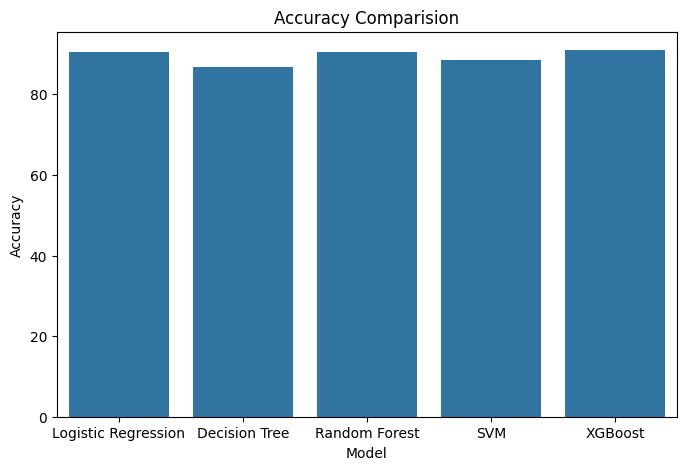

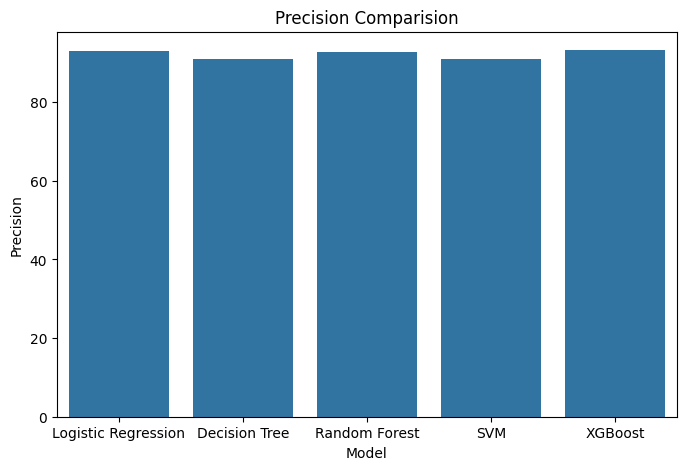

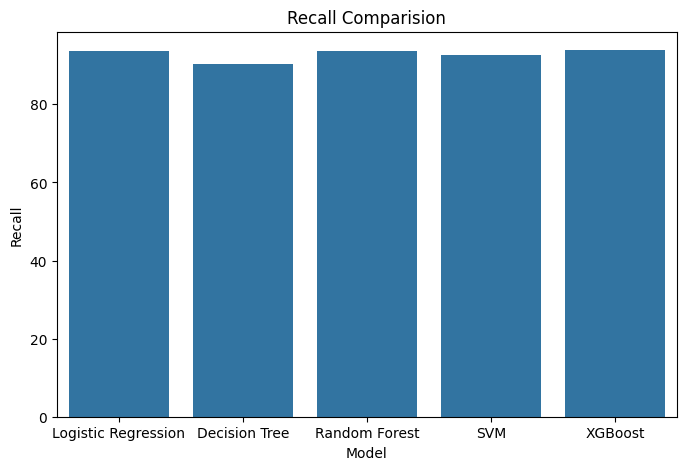

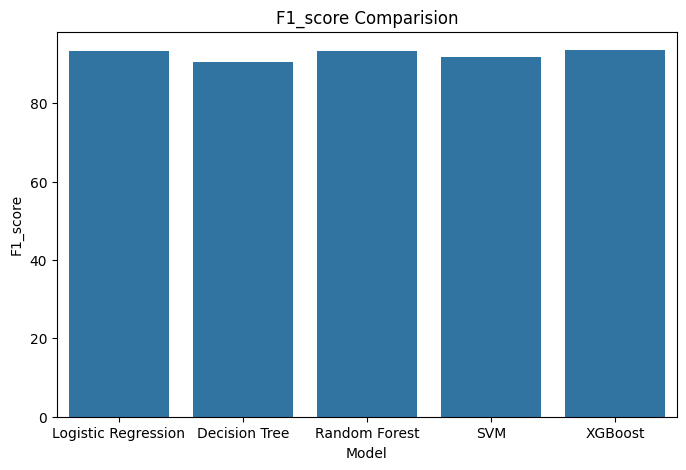

In [234]:
a=["Accuracy","Precision","Recall","F1_score"]
for i in a:
  plt.figure(figsize=(8,5))

  sns.barplot(data=comparison,x="Model",y=i)
  plt.title(f"{i} Comparision")
  plt.show()

# Final model with highest Accuracy

In [236]:
print("Final Model Accuracy :\n", comparison.loc[comparison["Accuracy"].idxmax()])

Final Model Accuracy :
 Model          XGBoost
Accuracy          91.0
Precision    93.271737
Recall       93.894586
F1_score     93.582125
Name: 4, dtype: object


# Take  XGBoost
Because XGBoost give highest Accuracy



In [237]:
cm=confusion_matrix(test_y,xgb_pred)
cm

array([[1523,  284],
       [ 256, 3937]])

Text(50.722222222222214, 0.5, 'Predicted')

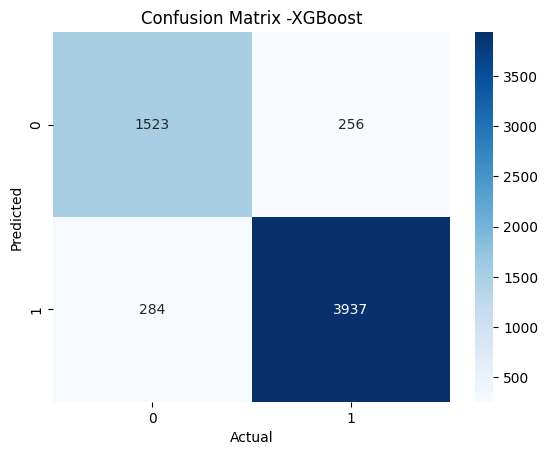

In [238]:
sns.heatmap(cm.T,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix -XGBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")

#Feature Importance



In [239]:

pd.DataFrame({"Features":x.columns,"importance":rf.feature_importances_})



,Features,importance
0,years_experience,0.277226
1,skills_match_score,0.160148
2,education_level,0.033426
3,project_count,0.168236
4,resume_length,0.134617
5,github_activity,0.226347
